In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import EDA as eda 
import Feature_eng as feature_eng
importlib.reload(eda)
importlib.reload(feature_eng)



<module 'Feature_eng' from 'c:\\Users\\Alexander  Hassfjell\\Documents\\Usyd\\Machine learning in buisness analytics\\ML project\\QBUS3820-Group-Assignment\\Feature_eng.py'>

In [4]:
churn, churn_train, churn_valid, churn_test = feature_eng.churn(eda.transactions, threshold_days=21)
print(churn.head())
print(churn.value_counts())
print(80*'=')
print(churn_train.value_counts())
print(churn_valid.value_counts())
print(churn_test.value_counts())

household_id
1    0
2    1
3    0
4    1
5    1
Name: churn, dtype: int64
churn
0    1897
1     572
Name: count, dtype: int64
churn
0    1332
1     396
Name: count, dtype: int64
churn
0    289
1     81
Name: count, dtype: int64
churn
0    276
1     95
Name: count, dtype: int64


              spend_trend
household_id             
1                0.649282
2               -0.234259
3                0.000000
4                3.189885
5                0.000000
...                   ...
2496             0.159576
2497             2.874545
2498            -0.136628
2499            -0.676195
2500            -0.161142

[2235 rows x 1 columns]
spend_trend shape: (2235, 1)
churn_aligned shape: (2235,)


c:\Users\Alexander  Hassfjell\Documents\Usyd\Machine learning in buisness analytics\ML project\QBUS3820-Group-Assignment\EDA.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_results['MI'], y=mi_results.index, palette='viridis')


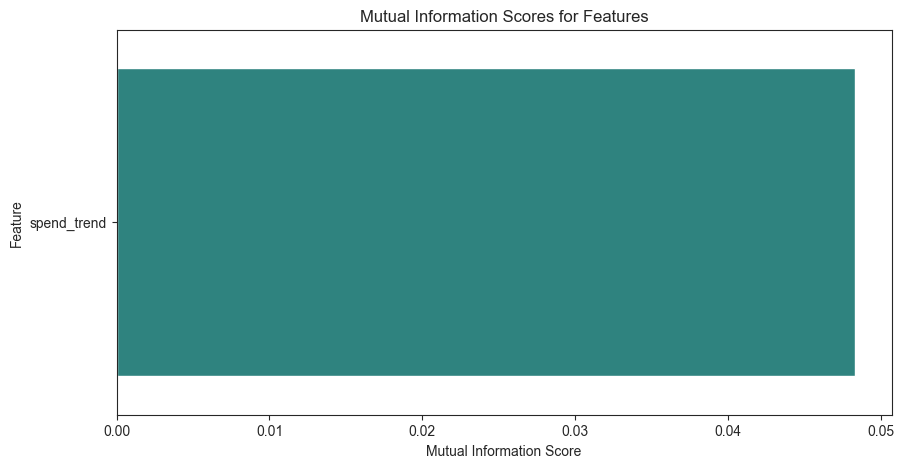

,MI
spend_trend,0.048258


In [5]:
spend_trend = feature_eng.spend_trend(eda.transactions)
print(spend_trend)

# Align churn with spend_trend (filter to matching households)
churn_aligned = churn[churn.index.isin(spend_trend.index)]
print(f"spend_trend shape: {spend_trend.shape}")
print(f"churn_aligned shape: {churn_aligned.shape}")

# Plot spend trend vs churn using mutual information
eda.mutual_information_table(spend_trend, target=churn_aligned, continuous=list(spend_trend.columns))

              visit_trend
household_id             
1                0.367089
2               -0.163265
3                0.000000
4                1.571429
5                0.000000
...                   ...
2496            -0.019048
2497             1.772727
2498            -0.068966
2499            -0.695035
2500            -0.489796

[2235 rows x 1 columns]
visit_trend shape: (2235, 1)
churn_aligned shape: (2235,)


c:\Users\Alexander  Hassfjell\Documents\Usyd\Machine learning in buisness analytics\ML project\QBUS3820-Group-Assignment\EDA.py:281: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_results['MI'], y=mi_results.index, palette='viridis')


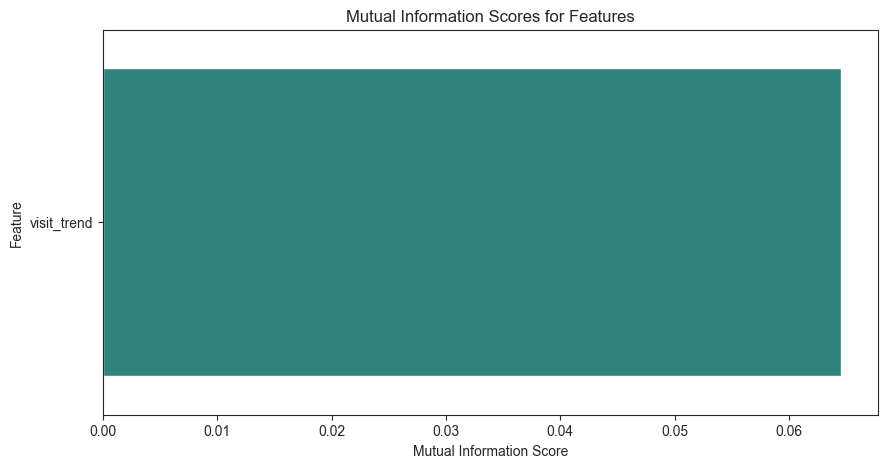

,MI
visit_trend,0.064529


In [7]:
visit_trend = feature_eng.visit_trend(eda.transactions)
print(visit_trend)

# Align churn with visit_trend (filter to matching households)
churn_aligned = churn[churn.index.isin(visit_trend.index)]
print(f"visit_trend shape: {visit_trend.shape}")
print(f"churn_aligned shape: {churn_aligned.shape}")

# Plot visit trend vs churn using mutual information
eda.mutual_information_table(visit_trend, target=churn_aligned, continuous=list(visit_trend.columns))